# 02_run-multi-match-prediction

This notebook simulates all selected team-vs-team matchups and builds matrix-style outputs for:

- row-team win probability
- draw probability
- column-team win probability
- most common exact score
- recommended score tip
- expected points for the recommended tip


In [1]:
import itertools
import os
import random
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

import joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

from utils.simulation import (
    build_matchup_detail_tables,
    find_optimal_tip_from_simulations,
    mirror_matchup_detail_tables,
    simulate_match_many,
)

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

@contextmanager
def tqdm_joblib(tqdm_object):
    """Patch joblib to report finished batches into a tqdm progress bar."""
    original_callback = joblib.parallel.BatchCompletionCallBack

    class TqdmBatchCompletionCallback(original_callback):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(self.batch_size)
            return super().__call__(*args, **kwargs)

    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = original_callback
        tqdm_object.close()


def format_elapsed_seconds(total_seconds):
    total_seconds = max(0.0, float(total_seconds))
    minutes, seconds = divmod(total_seconds, 60)
    hours, minutes = divmod(int(minutes), 60)
    if hours:
        return f'{hours:d}h {minutes:d}m {seconds:0.1f}s'
    if minutes:
        return f'{minutes:d}m {seconds:0.1f}s'
    return f'{seconds:0.1f}s'

## Configuration

Adjust `phase` and `n_simulations_per_match` depending on the use case.

Scoreline sampling now uses Poisson only.

For a first run, keep the team list small and use fewer simulations. For final outputs, increase the number of simulations and include all relevant teams.

In [3]:
phase = 'group' # one of 'group', 'round_of_32', 'round_of_16', 'quarterfinal', 'semifinal', 'third_place', 'final'

n_simulations_per_match = 10_000 # Number of simulations to run per matchup
max_tip_goals = 6 # Cutoff for maximum goals to consider in the tip optimization
use_cached_results = False # Use pre-existing results if available, otherwise run simulations
n_jobs = max(1, (os.cpu_count() or 1) - 1) # Set to 1 for sequential execution
parallel_backend = 'loky' # 'loky' backend uses separate worker processes and works well for CPU-bound tasks

scoreline_method_suffix = ''
dir_out = Path(f'simulation_results/{phase}')
dir_out.mkdir(parents=True, exist_ok=True)
path_cache = dir_out / f'prediction_matrix_long_{phase}{scoreline_method_suffix}.csv'

detail_cache_paths = {
    'score_distribution': (
        dir_out / f'matchup_score_distribution_{phase}{scoreline_method_suffix}.csv'
    ),
    'outcome_distribution': (
        dir_out / f'matchup_outcome_distribution_{phase}{scoreline_method_suffix}.csv'
    ),
    'goal_diff_distribution': (
        dir_out / f'matchup_goal_diff_distribution_{phase}{scoreline_method_suffix}.csv'
    ),
    'tip_rank': dir_out / f'matchup_tip_rank_{phase}{scoreline_method_suffix}.csv',
}
detail_table_names = list(detail_cache_paths)


In [4]:
from utils.simulation import groups

# Select teams per phase
dir_teams = {
    'group': sorted(set(team for group_teams in groups.values() for team in group_teams)),
    'round_of_32': None, # tbd
    'round_of_16': None, # tbd
    'quarterfinal': None, # tbd
    'semifinal': None, # tbd
    'third_place': None, # tbd
    'final': None, # tbd
}
teams = sorted(dir_teams[phase])
n_ordered_matrix_cells = len(teams) * (len(teams) - 1)
n_simulated_matchups = len(teams) * (len(teams) - 1) // 2

print(f'Teams: {len(teams)}')
print(f'Simulated matchups: {n_simulated_matchups:,}')
print(f'Simulations per matchup: {n_simulations_per_match:,}')
print(f'Parallel workers: {n_jobs}')
print(
    'Total simulated matches: '
    f'{n_simulated_matchups * n_simulations_per_match:,}'
)

Teams: 48
Simulated matchups: 1,128
Simulations per matchup: 10,000
Parallel workers: 11
Total simulated matches: 11,280,000


## Matchup summary helper

This helper runs one row-team vs column-team simulation and returns both the matrix-ready summary row and the detailed distributions needed to rebuild the single-match 2x2 view later.

In [5]:
def simulate_matchup_tables(
    team_a,
    team_b,
    phase='group',
    n_simulations=3000,
    max_tip_goals=6,
    use_tqdm=False
):
    """Simulate one matchup and return summary and detail tables.

    Args:
        team_a: Row team.
        team_b: Column team.
        phase: Prediction-game phase
        n_simulations: Number of Monte Carlo simulations.
        max_tip_goals: Highest goals to consider for candidate score tips.

    Returns:
        Dictionary with summary and detail tables for this matchup.
    """
    df_simulations = simulate_match_many(
        team_a=team_a,
        team_b=team_b,
        phase=phase,
        n_simulations=n_simulations,
        use_tqdm=use_tqdm
    )

    df_tiprank = find_optimal_tip_from_simulations(
        df_simulations=df_simulations,
        team_a=team_a,
        team_b=team_b,
        phase=phase,
        max_tip_goals=max_tip_goals,
    )

    return build_matchup_detail_tables(
        df_simulations=df_simulations,
        df_tiprank=df_tiprank,
        team_a=team_a,
        team_b=team_b,
    )


## Run all matchups

The matrix is row-oriented: `team_a` is the row team and `team_b` is the column opponent.

Each unordered matchup is simulated once, then mirrored into the opposite direction.
For example, `Switzerland vs Brazil` is simulated directly, and `Brazil vs Switzerland`
is derived by swapping teams, probabilities, goals, and score tips.

This avoids running the same neutral matchup twice and keeps the matrix symmetric.

In [6]:
detail_table_display_names = {
    'score_distribution': 'score distributions',
    'outcome_distribution': 'outcome distributions',
    'goal_diff_distribution': 'goal-difference distributions',
    'tip_rank': 'tip ranks',
}

In [7]:
detail_cache_ready = all(path.exists() for path in detail_cache_paths.values())
df_matrix_long = None
df_matchup_details = None

def run_matchup_pair(team_a, team_b):
    matchup_tables = simulate_matchup_tables(
        team_a=team_a,
        team_b=team_b,
        phase=phase,
        n_simulations=n_simulations_per_match,
        max_tip_goals=max_tip_goals,
    )
    mirrored_matchup_tables = mirror_matchup_detail_tables(matchup_tables)
    return matchup_tables, mirrored_matchup_tables

matrix_run_started_at = time.perf_counter()
matrix_result_source = 'cache'

if use_cached_results and path_cache.exists() and detail_cache_ready:
    df_matrix_long = pd.read_csv(path_cache)
    df_matchup_details = {
        name: pd.read_csv(path)
        for name, path in detail_cache_paths.items()
    }
    print(f'Loaded cached results from: {path_cache}')
    for name, path in detail_cache_paths.items():
        print(f'Loaded cached {detail_table_display_names[name]} from: {path}')
else:
    matrix_result_source = 'simulation'
    if use_cached_results and path_cache.exists() and not detail_cache_ready:
        print('Summary cache exists, but matchup detail caches are incomplete. Re-running simulations.')

    rows = []
    detail_rows = {name: [] for name in detail_table_names}
    matchups = list(itertools.combinations(teams, 2))

    if n_jobs == 1:
        print('Running simulations sequentially.')
        matchup_results = [
            run_matchup_pair(team_a, team_b)
            for team_a, team_b in tqdm(matchups, desc='Simulating matchups', unit='matchup')
        ]
    else:
        print(f'Running simulations in parallel with {n_jobs} workers ({parallel_backend} backend).')
        progress_bar = tqdm(total=len(matchups), desc='Simulating matchups', unit='matchup')
        with tqdm_joblib(progress_bar):
            matchup_results = Parallel(n_jobs=n_jobs, backend=parallel_backend)(
                delayed(run_matchup_pair)(team_a, team_b)
                for team_a, team_b in matchups
            )

    for matchup_tables, mirrored_matchup_tables in matchup_results:
        rows.append(matchup_tables['summary'])
        rows.append(mirrored_matchup_tables['summary'])

        for name in detail_table_names:
            detail_rows[name].append(matchup_tables[name])
            detail_rows[name].append(mirrored_matchup_tables[name])

    df_matrix_long = pd.DataFrame(rows)
    df_matchup_details = {
        name: pd.concat(tables, ignore_index=True)
        for name, tables in detail_rows.items()
    }

    df_matrix_long.to_csv(path_cache, index=False)
    print(f'Saved long-format results to: {path_cache}')

    for name, path in detail_cache_paths.items():
        df_matchup_details[name].to_csv(path, index=False)
        print(f'Saved {detail_table_display_names[name]} to: {path}')

matrix_run_elapsed_seconds = time.perf_counter() - matrix_run_started_at
n_matchups_processed = len(df_matrix_long) // 2
avg_seconds_per_matchup = (
    matrix_run_elapsed_seconds / n_matchups_processed
    if n_matchups_processed
    else float('nan')
)

print(
    f"Matrix data ready from {matrix_result_source} in "
    f"{format_elapsed_seconds(matrix_run_elapsed_seconds)} "
    f"({avg_seconds_per_matchup:0.2f}s per simulated matchup)."
)

df_matrix_long.head()

Running simulations in parallel with 11 workers (loky backend).


Simulating matchups:   0%|          | 0/1128 [00:00<?, ?matchup/s]

Saved long-format results to: simulation_results\group\prediction_matrix_long_group.csv
Saved score distributions to: simulation_results\group\matchup_score_distribution_group.csv
Saved outcome distributions to: simulation_results\group\matchup_outcome_distribution_group.csv
Saved goal-difference distributions to: simulation_results\group\matchup_goal_diff_distribution_group.csv
Saved tip ranks to: simulation_results\group\matchup_tip_rank_group.csv
Matrix data ready from simulation in 5h 3m 29.2s (16.14s per simulated matchup).


,team_a,team_b,team_a_win_probability,draw_probability,team_b_win_probability,most_common_score,most_common_score_probability,recommended_tip,recommended_tip_outcome,recommended_tip_expected_points,recommended_tip_exact_probability,avg_goals_a,avg_goals_b,avg_goal_difference
0,Algeria,Argentina,13.15,26.13,60.72,0-1,15.89,0-1,Argentina win,4.6999,15.89,0.6918,1.6611,-0.9693
1,Argentina,Algeria,60.72,26.13,13.15,1-0,15.89,1-0,Algeria win,4.6999,15.89,1.6611,0.6918,0.9693
2,Algeria,Australia,29.24,34.06,36.70,1-1,15.84,1-1,Draw,3.4714,15.84,1.0092,1.1306,-0.1214
3,Australia,Algeria,36.70,34.06,29.24,1-1,15.84,1-1,Draw,3.4714,15.84,1.1306,1.0092,0.1214
4,Algeria,Austria,37.04,30.48,32.48,1-1,14.71,1-1,Draw,3.1778,14.71,1.2151,1.1050,0.1101


## Create matrix tables

In [19]:
def make_matrix(value_column):
    """Return a team-vs-team matrix for a selected value column."""
    return (
        df_matrix_long
        .pivot(index='team_a', columns='team_b', values=value_column)
        .reindex(index=teams, columns=teams)
    )


df_row_win_matrix = make_matrix('team_a_win_probability')
df_draw_matrix = make_matrix('draw_probability')
df_col_win_matrix = make_matrix('team_b_win_probability')
df_tip_matrix = make_matrix('recommended_tip')
df_tip_points_matrix = make_matrix('recommended_tip_expected_points')
df_score_matrix = make_matrix('most_common_score')
df_score_probability_matrix = make_matrix('most_common_score_probability')
df_avg_goal_diff_matrix = make_matrix('avg_goal_difference')

df_row_win_matrix.head()


team_b,Algeria,Argentina,Australia,Austria,Belgium,Bosnia and Herzegovina,Brazil,Canada,Cape Verde,Colombia,Croatia,Curaçao,Czech Republic,DR Congo,Ecuador,Egypt,England,France,Germany,Ghana,Haiti,Iran,Iraq,Ivory Coast,Japan,Jordan,Mexico,Morocco,Netherlands,New Zealand,Norway,Panama,Paraguay,Portugal,Qatar,Saudi Arabia,Scotland,Senegal,South Africa,South Korea,Spain,Sweden,Switzerland,Tunisia,Turkey,United States,Uruguay,Uzbekistan
team_a,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Algeria,NaN,13.15,29.24,37.04,23.46,64.47,26.21,33.41,54.12,32.63,20.82,61.11,54.18,45.75,39.05,36.29,20.65,13.08,26.23,50.53,62.53,29.22,52.60,35.53,21.85,59.69,24.18,16.58,20.12,47.05,36.96,36.38,52.76,18.17,57.49,54.95,48.07,31.46,55.80,26.92,13.81,56.12,29.73,52.22,35.09,25.51,31.89,53.53
Argentina,60.72,NaN,67.60,72.76,66.04,75.80,39.18,66.76,65.60,37.84,56.61,78.82,78.03,77.29,62.96,74.54,50.41,37.75,56.18,68.75,70.65,66.93,78.25,74.85,65.40,74.11,63.99,56.11,61.28,63.58,76.27,71.18,53.47,58.30,75.23,78.96,77.59,65.48,78.37,69.05,40.91,83.14,69.58,76.38,75.32,68.59,63.28,73.72
Australia,36.70,9.78,NaN,38.68,25.48,68.24,26.38,35.66,59.87,32.79,21.53,65.62,56.24,54.73,39.94,35.21,22.01,12.74,25.73,54.00,65.68,29.24,57.28,39.53,19.76,62.40,23.17,15.95,19.86,48.21,40.52,38.50,55.33,18.49,61.00,54.92,51.49,25.23,61.68,32.96,15.40,57.75,29.48,52.39,37.97,26.74,33.00,49.73
Austria,32.48,6.70,32.28,NaN,21.13,55.58,20.66,33.88,50.56,27.58,16.55,58.68,52.05,47.76,37.55,31.12,15.49,10.97,21.38,43.08,58.46,25.15,49.31,35.18,17.03,58.39,18.38,12.90,15.23,43.71,32.80,33.61,51.19,14.52,53.23,53.41,42.39,18.53,56.80,24.35,12.75,52.70,24.05,50.95,35.14,20.82,27.05,49.63
Belgium,47.29,10.57,49.01,52.18,NaN,68.30,34.99,55.28,66.60,46.65,36.84,75.62,62.81,66.16,63.25,57.70,22.15,17.20,34.37,64.95,75.08,55.01,67.60,61.78,41.64,73.35,45.08,24.39,31.95,60.51,60.11,59.63,69.58,25.01,70.81,68.93,67.45,39.51,69.77,55.15,19.70,71.34,52.80,64.16,62.23,42.46,49.38,61.56


## Save matrix outputs

This writes the matrix CSVs used for high-level comparison. Matchup-level detail distributions are already persisted in the previous step for the interactive notebook.

In [20]:
matrix_outputs = {
    f'row_team_win_probability_matrix_{phase}{scoreline_method_suffix}.csv': df_row_win_matrix,
    f'draw_probability_matrix_{phase}{scoreline_method_suffix}.csv': df_draw_matrix,
    f'column_team_win_probability_matrix_{phase}{scoreline_method_suffix}.csv': df_col_win_matrix,
    f'recommended_tip_matrix_{phase}{scoreline_method_suffix}.csv': df_tip_matrix,
    f'recommended_tip_expected_points_matrix_{phase}{scoreline_method_suffix}.csv': df_tip_points_matrix,
    f'most_common_score_matrix_{phase}{scoreline_method_suffix}.csv': df_score_matrix,
    f'most_common_score_probability_matrix_{phase}{scoreline_method_suffix}.csv': (
        df_score_probability_matrix
    ),
    f'avg_goal_difference_matrix_{phase}{scoreline_method_suffix}.csv': df_avg_goal_diff_matrix,
}

for filename, df_output in matrix_outputs.items():
    path_out = dir_out / filename
    df_output.to_csv(path_out)
    print(f'Saved: {path_out}')


Saved: simulation_results\group\row_team_win_probability_matrix_group.csv
Saved: simulation_results\group\draw_probability_matrix_group.csv
Saved: simulation_results\group\column_team_win_probability_matrix_group.csv
Saved: simulation_results\group\recommended_tip_matrix_group.csv
Saved: simulation_results\group\recommended_tip_expected_points_matrix_group.csv
Saved: simulation_results\group\most_common_score_matrix_group.csv
Saved: simulation_results\group\most_common_score_probability_matrix_group.csv
Saved: simulation_results\group\avg_goal_difference_matrix_group.csv


## Plot: win probability matrix

Cell values show the probability that the row team beats the column team.


In [21]:
n_teams = len(df_tip_matrix)
cell_size = 0.25
margin = 4
fig_size = n_teams * cell_size + margin

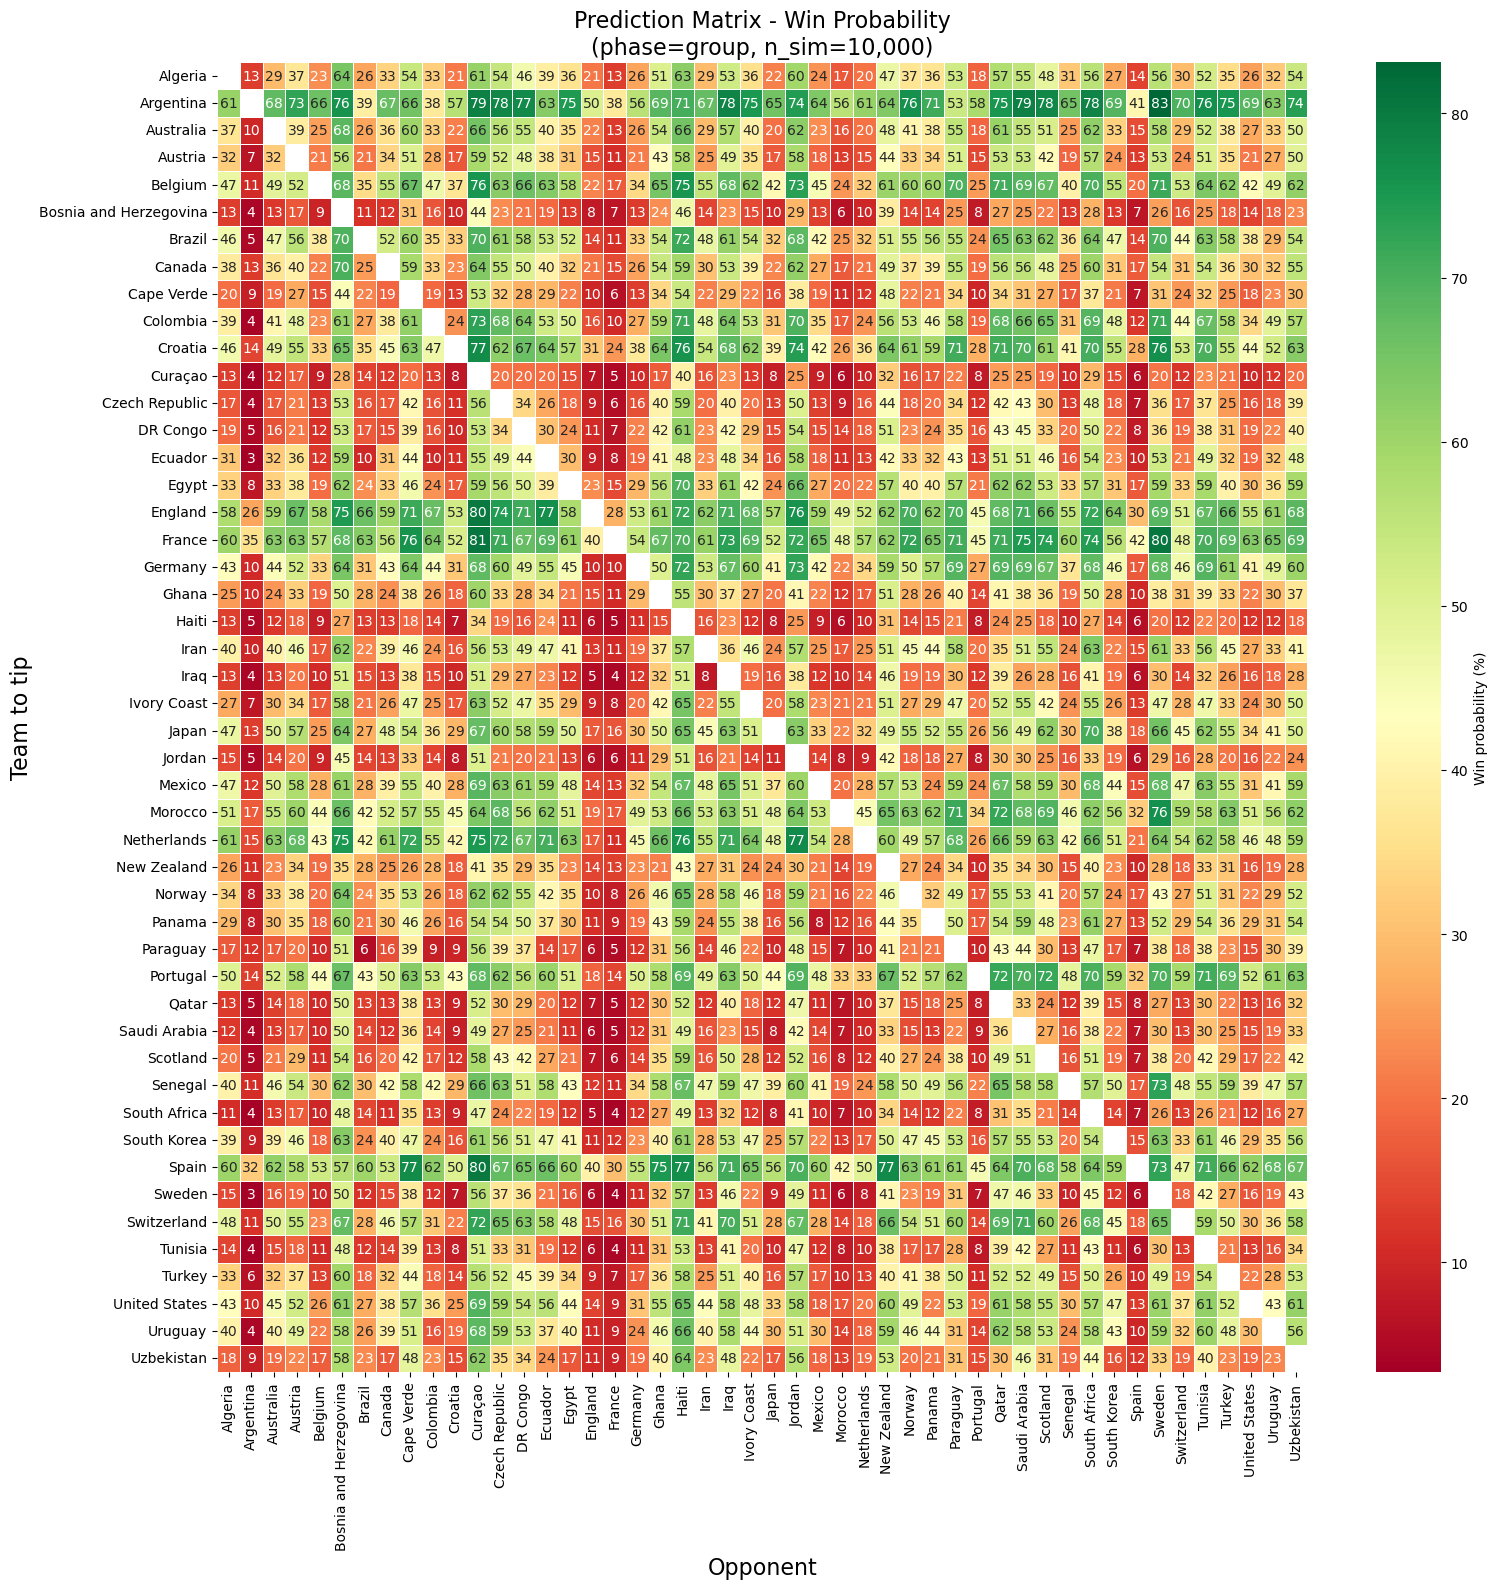

In [22]:
plt.figure(figsize=(fig_size, fig_size))

sns.heatmap(
    df_row_win_matrix,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Win probability (%)'},
)

plt.title(
    f'Prediction Matrix - Win Probability'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
)
plt.xlabel('Opponent', fontsize=16)
plt.ylabel('Team to tip', fontsize=16)
plt.tight_layout()
plt.show()


## Plot: recommended tip matrix

Cell text shows the recommended score tip. Colour shows the expected points of that tip.


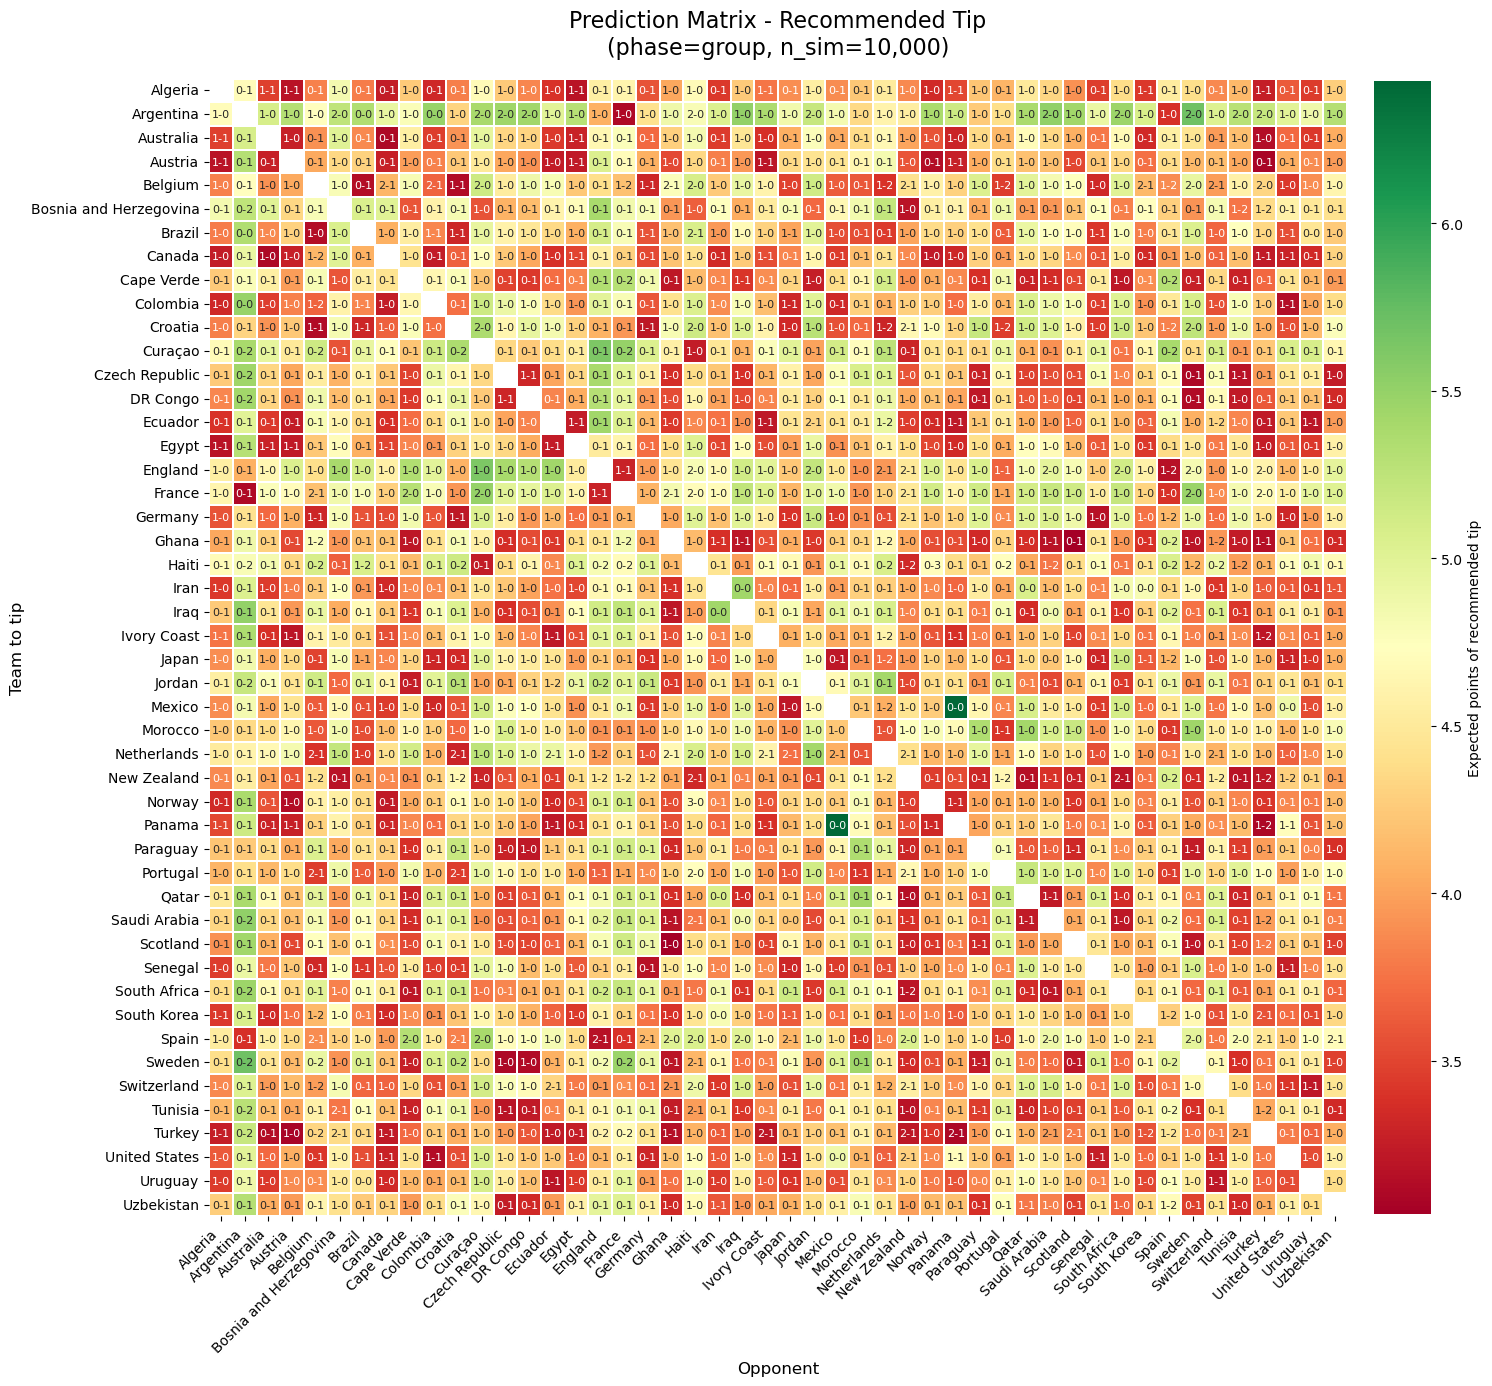

In [23]:
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    df_tip_points_matrix,
    annot=df_tip_matrix,
    fmt='',
    cmap='RdYlGn',
    linewidths=0.25,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={
        'label': 'Expected points of recommended tip',
        'shrink': 0.75,
        'pad': 0.02,
    },
    annot_kws={
        'fontsize': 8,
        'ha': 'center',
        'va': 'center',
    },
)

ax.set_title(
    f'Prediction Matrix - Recommended Tip'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
    pad=18,
)

ax.set_xlabel('Opponent', fontsize=12)
ax.set_ylabel('Team to tip', fontsize=12)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

plt.tight_layout()
plt.show()

## Plot: most common exact score matrix

Cell text shows the most common exact score. Colour shows how often that exact score appears in the simulations.


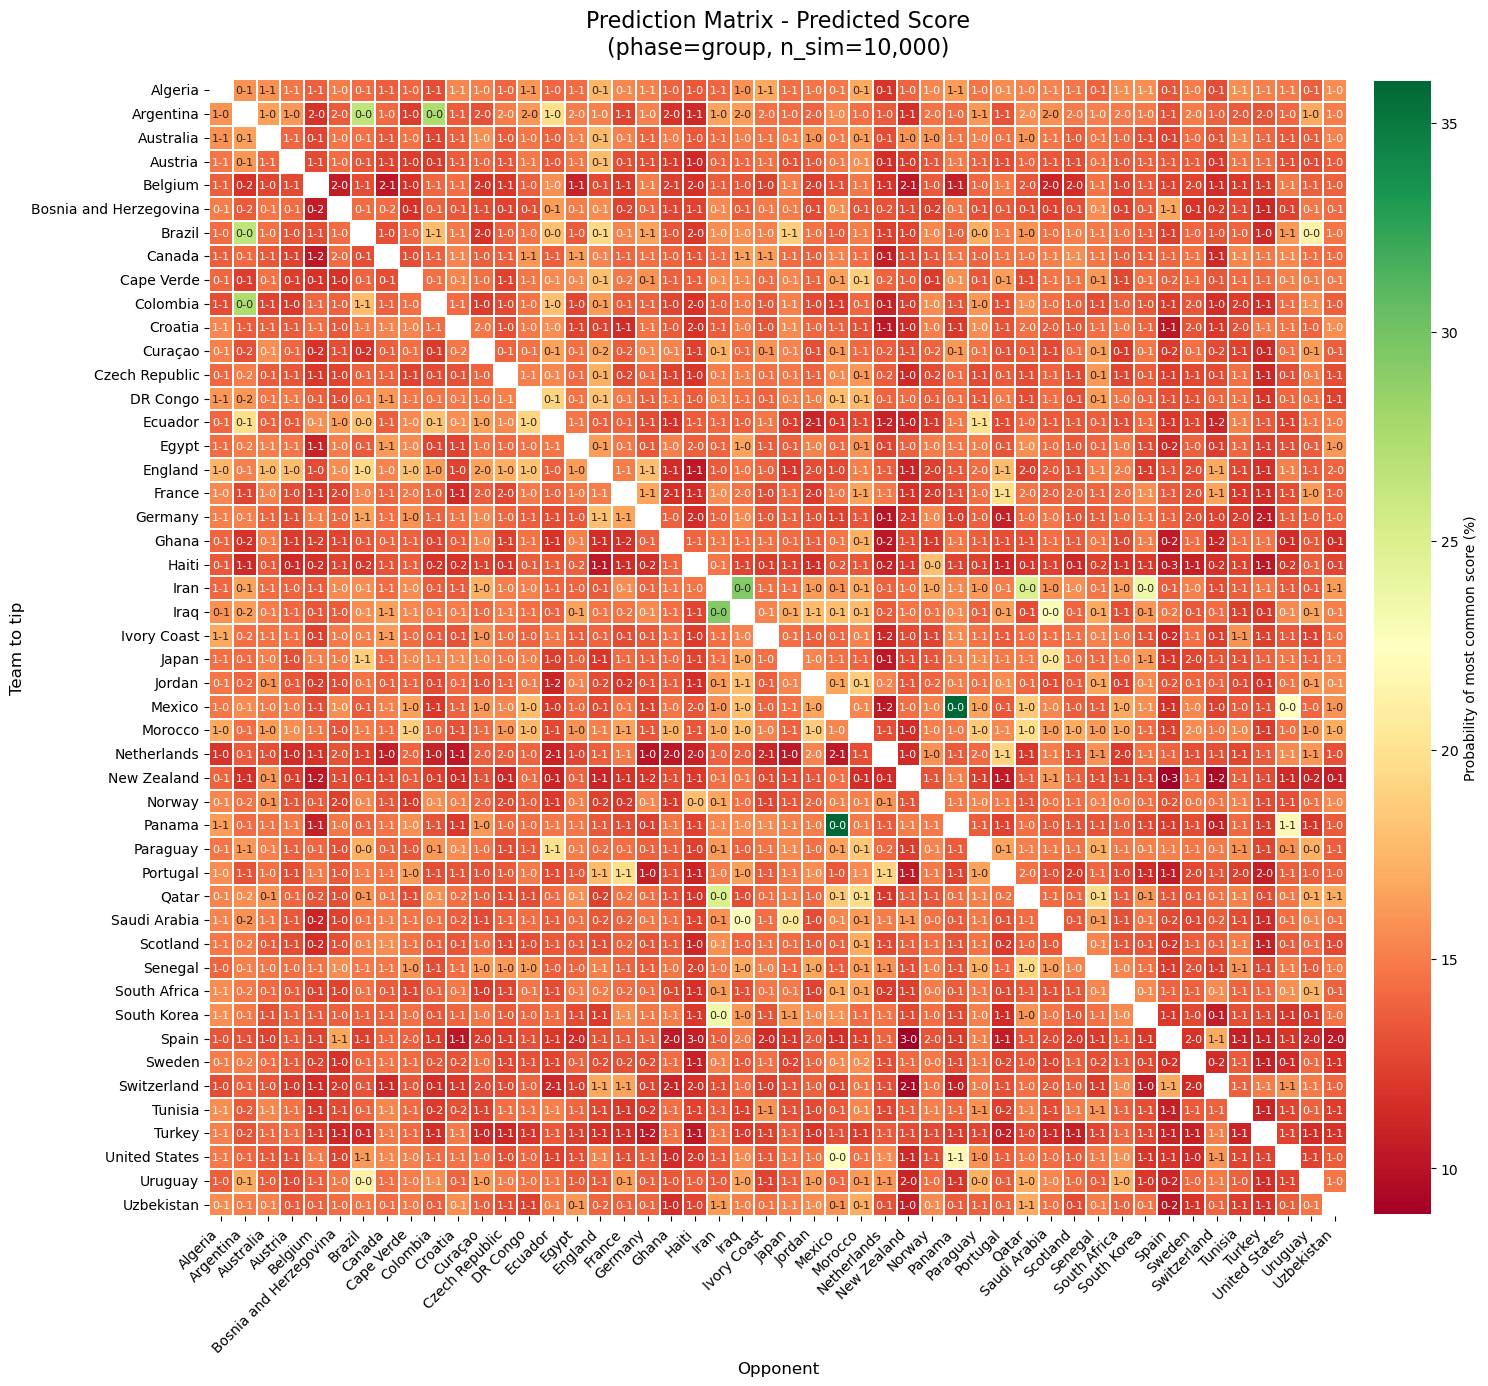

In [24]:
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    df_score_probability_matrix,
    annot=df_score_matrix,
    fmt='',
    cmap='RdYlGn',
    linewidths=0.25,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={
        'label': 'Probability of most common score (%)',
        'shrink': 0.75,
        'pad': 0.02,
    },
    annot_kws={
        'fontsize': 8,
        'ha': 'center',
        'va': 'center',
    },
)

ax.set_title(
    f'Prediction Matrix - Predicted Score'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
    pad=18,
)

ax.set_xlabel('Opponent', fontsize=12)
ax.set_ylabel('Team to tip', fontsize=12)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

plt.tight_layout()
plt.show()

## Plot: average goal-difference matrix

Positive values favour the row team. Negative values favour the column team.


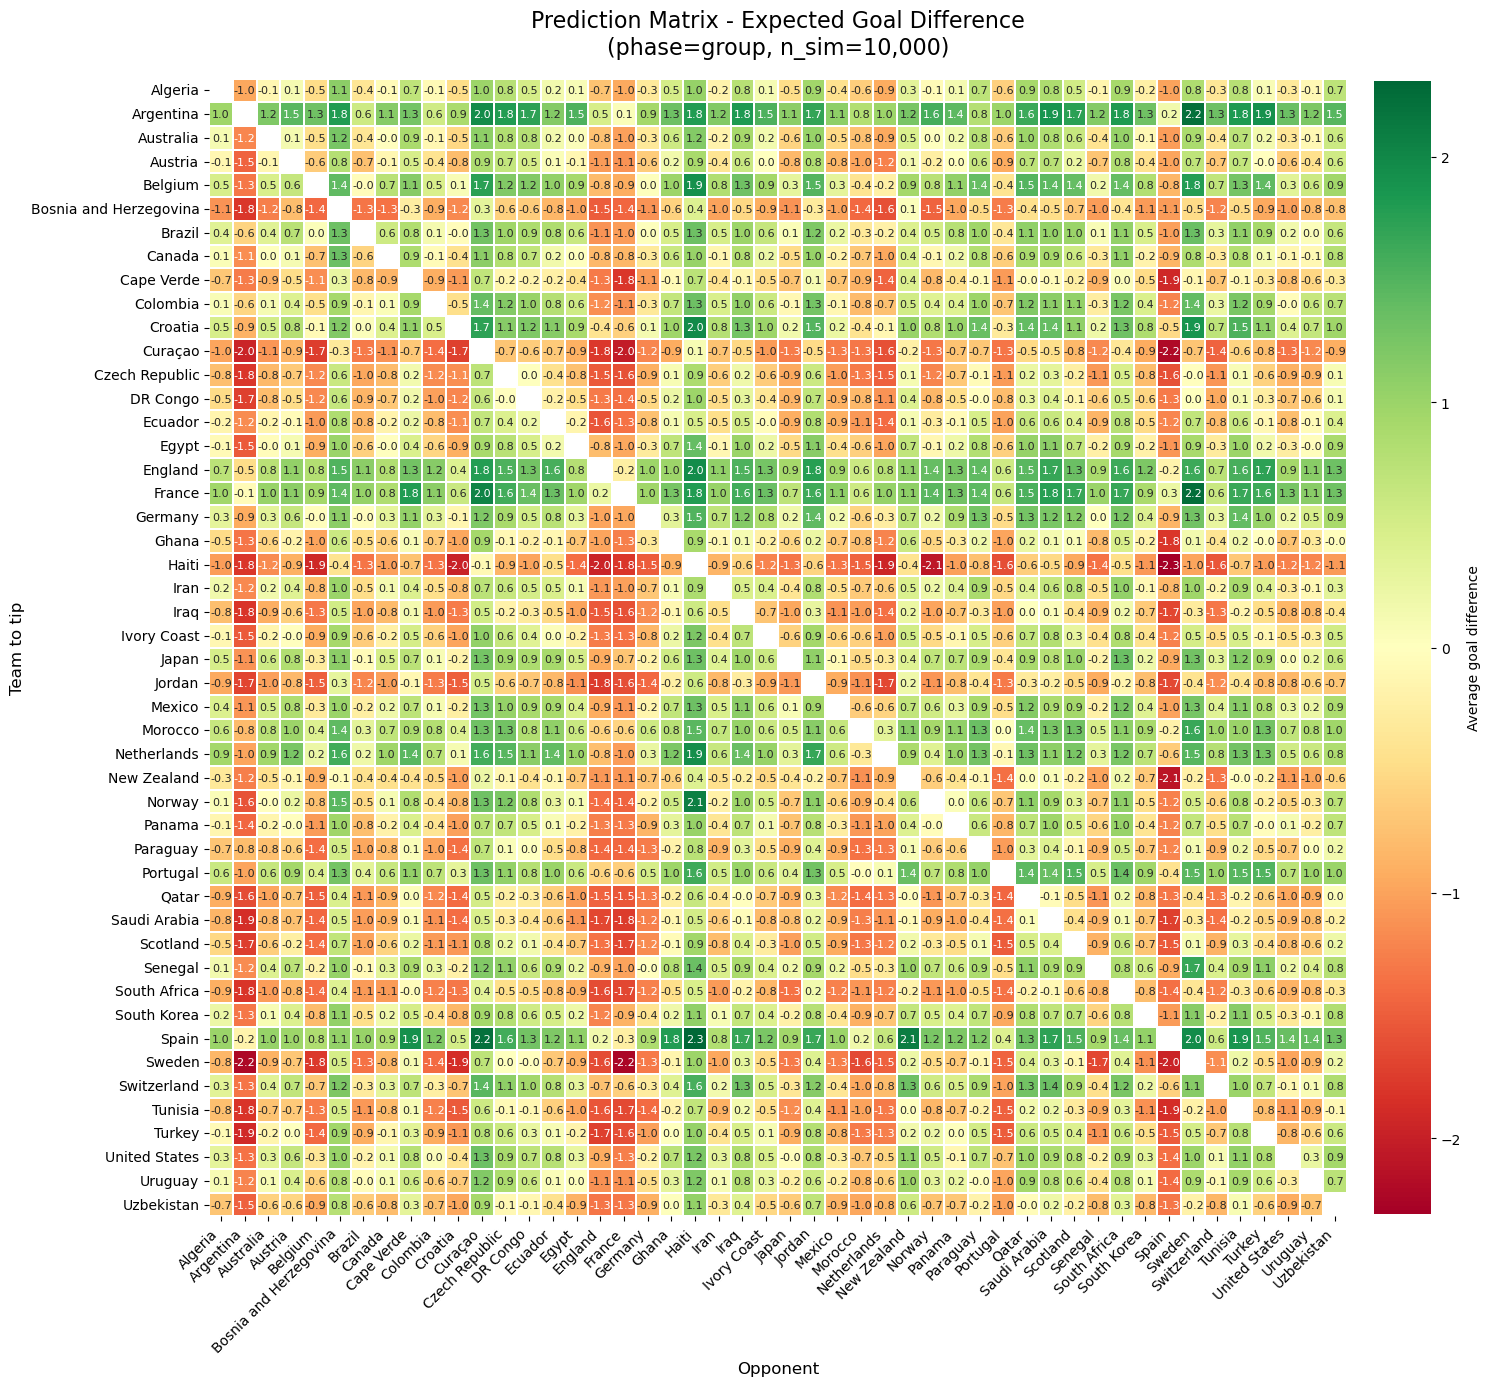

In [25]:
goal_diff_abs_max = np.nanmax(np.abs(df_avg_goal_diff_matrix.values))

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(
    df_avg_goal_diff_matrix,
    annot=True,
    fmt='.1f',
    vmin=-goal_diff_abs_max,
    vmax=goal_diff_abs_max,
    cmap='RdYlGn',
    linewidths=0.25,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={
        'label': 'Average goal difference',
        'shrink': 0.75,
        'pad': 0.02,
    },
    annot_kws={
        'fontsize': 8,
        'ha': 'center',
        'va': 'center',
    },
)

ax.set_title(
    f'Prediction Matrix - Expected Goal Difference'
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=16,
    # fontweight='bold',
    pad=18,
)

ax.set_xlabel('Opponent', fontsize=12)
ax.set_ylabel('Team to tip', fontsize=12)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10,
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10,
)

plt.tight_layout()
plt.show()

## Team ranking summary

This summarizes each row team's average performance across all selected opponents.


In [26]:
df_team_strength = (
    df_matrix_long
    .groupby('team_a')
    .agg(
        avg_win_probability=('team_a_win_probability', 'mean'),
        avg_draw_probability=('draw_probability', 'mean'),
        avg_loss_probability=('team_b_win_probability', 'mean'),
        avg_recommended_tip_expected_points=(
            'recommended_tip_expected_points',
            'mean',
        ),
        avg_goals_for=('avg_goals_a', 'mean'),
        avg_goals_against=('avg_goals_b', 'mean'),
        avg_goal_difference=('avg_goal_difference', 'mean'),
    )
    .sort_values('avg_win_probability', ascending=False)
)

df_team_strength


,avg_win_probability,avg_draw_probability,avg_loss_probability,avg_recommended_tip_expected_points,avg_goals_for,avg_goals_against,avg_goal_difference
team_a,,,,,,,
Argentina,66.459787,23.869149,9.671064,4.951321,1.986164,0.685102,1.301062
France,63.072766,25.735106,11.192128,4.642885,1.979130,0.792766,1.186364
England,61.697872,23.883404,14.418723,4.628832,1.904874,0.812119,1.092755
Spain,60.668936,24.843191,14.487872,4.419717,2.041466,0.874043,1.167423
Netherlands,54.767234,22.980851,22.251915,4.361774,1.792240,1.018451,0.773789
Morocco,54.320426,28.320000,17.359574,4.419734,1.574234,0.803472,0.770762
Portugal,53.967447,27.301064,18.731489,4.329991,1.702740,0.942806,0.759934
Croatia,53.317234,25.037234,21.645532,4.304874,1.670777,0.960077,0.710700
Belgium,52.721064,24.161489,23.117447,4.275115,1.755594,1.066021,0.689572


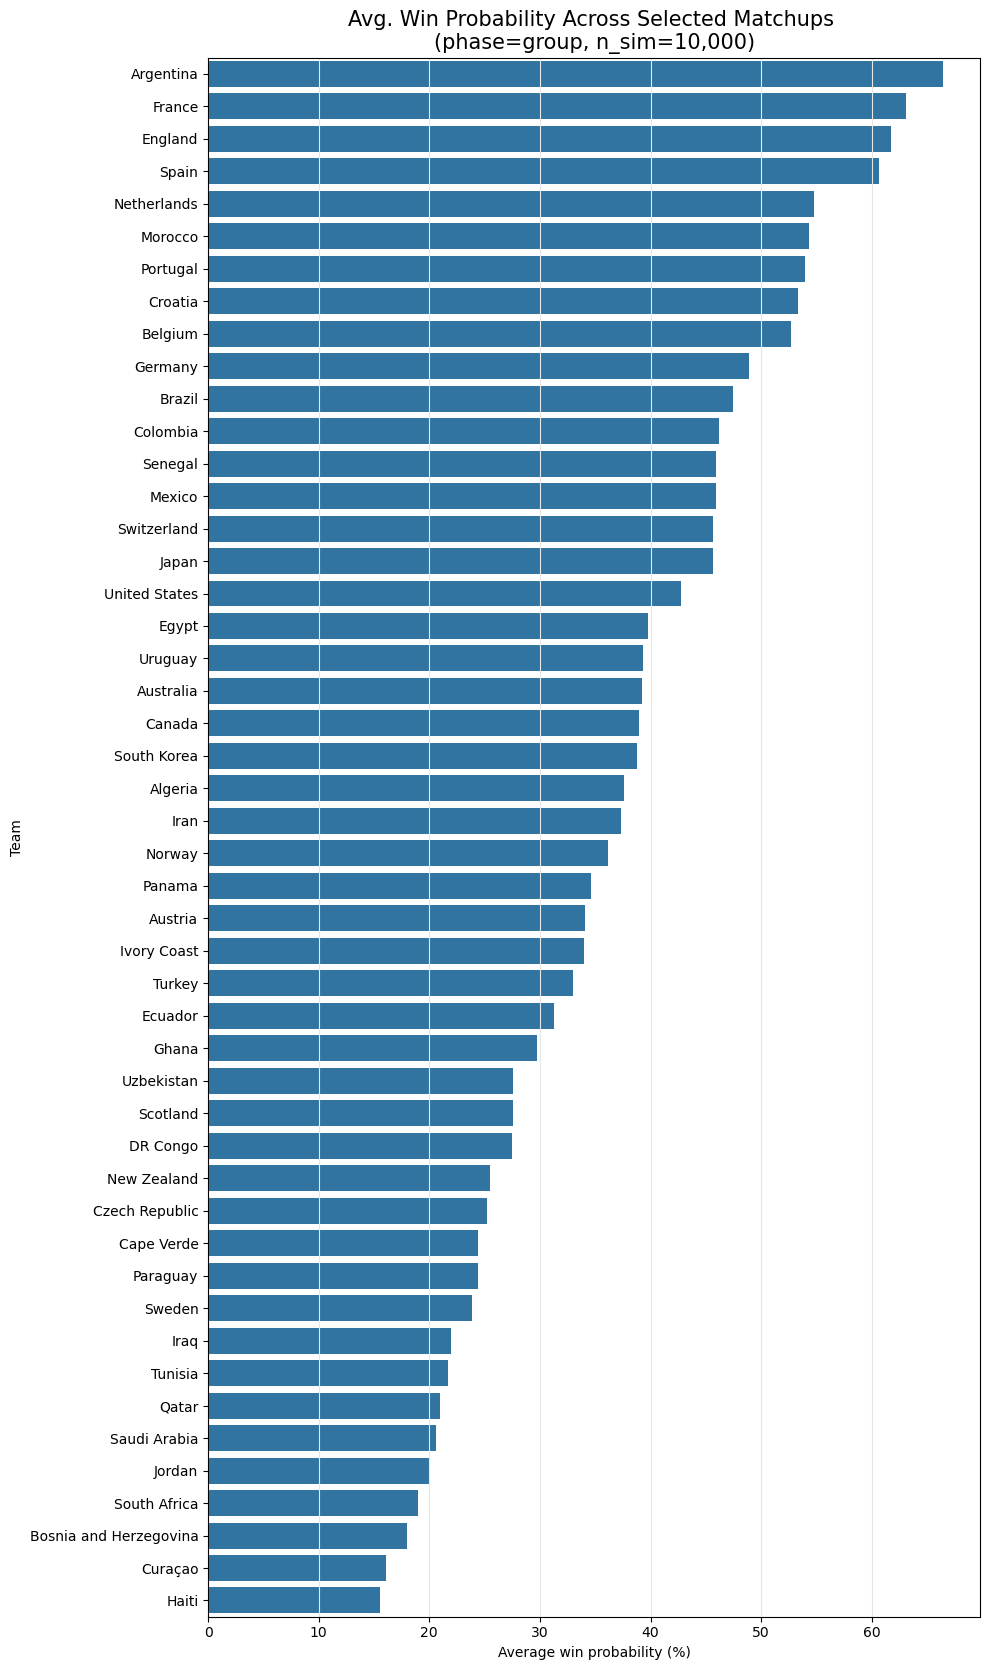

In [27]:
df_team_strength_plot = df_team_strength.reset_index()

plt.figure(figsize=(10, max(6, len(df_team_strength_plot) * 0.35)))

sns.barplot(
    data=df_team_strength_plot,
    x='avg_win_probability',
    y='team_a',
    color='#1f77b4',
)

plt.title(
    f'Avg. Win Probability Across Selected Matchups '
    f'\n(phase={phase}, n_sim={n_simulations_per_match:,})',
    fontsize=15,
    # fontweight='bold',
)
plt.xlabel('Average win probability (%)')
plt.ylabel('Team')
plt.grid(axis='x', color='#e6e6e6')
plt.tight_layout()
plt.show()


## Inspect one matchup

In [28]:
inspect_team_a = 'Switzerland'
inspect_team_b = 'Brazil'

df_matrix_long[
    (df_matrix_long['team_a'] == inspect_team_a)
    & (df_matrix_long['team_b'] == inspect_team_b)
]


,team_a,team_b,team_a_win_probability,draw_probability,team_b_win_probability,most_common_score,most_common_score_probability,recommended_tip,recommended_tip_outcome,recommended_tip_expected_points,recommended_tip_exact_probability,avg_goals_a,avg_goals_b,avg_goal_difference
605,Switzerland,Brazil,27.74,27.79,44.47,0-1,13.15,0-1,Switzerland win,3.6803,13.15,1.0297,1.3215,-0.2918


## Final summary

In [29]:
print('Prediction matrix complete.')
print(f'Teams: {len(teams)}')
print('Scoreline method: poisson')
print(f'Ordered matchups: {len(df_matrix_long):,}')
print(f'Simulations per matchup: {n_simulations_per_match:,}')
print(f'Total simulated matches: {len(df_matrix_long) * n_simulations_per_match:,}')
print()
print('Top teams by average win probability:')
display(df_team_strength.head(10))


Prediction matrix complete.
Teams: 48
Scoreline method: poisson
Ordered matchups: 2,256
Simulations per matchup: 10,000
Total simulated matches: 22,560,000

Top teams by average win probability:


,avg_win_probability,avg_draw_probability,avg_loss_probability,avg_recommended_tip_expected_points,avg_goals_for,avg_goals_against,avg_goal_difference
team_a,,,,,,,
Argentina,66.459787,23.869149,9.671064,4.951321,1.986164,0.685102,1.301062
France,63.072766,25.735106,11.192128,4.642885,1.979130,0.792766,1.186364
England,61.697872,23.883404,14.418723,4.628832,1.904874,0.812119,1.092755
Spain,60.668936,24.843191,14.487872,4.419717,2.041466,0.874043,1.167423
Netherlands,54.767234,22.980851,22.251915,4.361774,1.792240,1.018451,0.773789
Morocco,54.320426,28.320000,17.359574,4.419734,1.574234,0.803472,0.770762
Portugal,53.967447,27.301064,18.731489,4.329991,1.702740,0.942806,0.759934
Croatia,53.317234,25.037234,21.645532,4.304874,1.670777,0.960077,0.710700
Belgium,52.721064,24.161489,23.117447,4.275115,1.755594,1.066021,0.689572
